<a href="https://colab.research.google.com/github/AbeerProg/decRev_detection/blob/main/ModelsComp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TF: 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
EDL-DRD (full) feature shape: (25166, 2461)
Baselines feature shape: (25166, 7)
Shapes (text/mask/full_feats/base_feats): (25166, 100) (25166, 100) (25166, 2461) (25166, 7) | labels: (25166,)
Splits: 17615 3776 3775

▶ Training EDL-DRD
Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 62s 382ms/step - aux_out_accuracy: 0.7331 - aux_out_loss: 0.5216 - loss: 0.7367 - main_out_accuracy: 0.7186 - main_out_loss: 0.5802 - val_aux_out_accuracy: 0.8771 - val_aux_out_loss: 0.2838 - val_loss: 0.3731 - val_main_out_accuracy: 0.8700 - val_main_out_loss: 0.2892 - learning_rate: 0.0010
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 374ms/step - aux_out_accuracy: 0.8713 - aux_out_loss: 0.2906 - loss: 0.3965 - main_out_accuracy: 0.8650 - main_out_loss: 0.3093 - val_aux_out_accuracy: 0.8893 - val_aux_out_loss: 0.2572 - val_loss: 0.3329 - val_main_out_accuracy: 0.8877 - val_main_out_loss: 0.2567 - learning_rate: 0.0010
Epoch 3/10
13

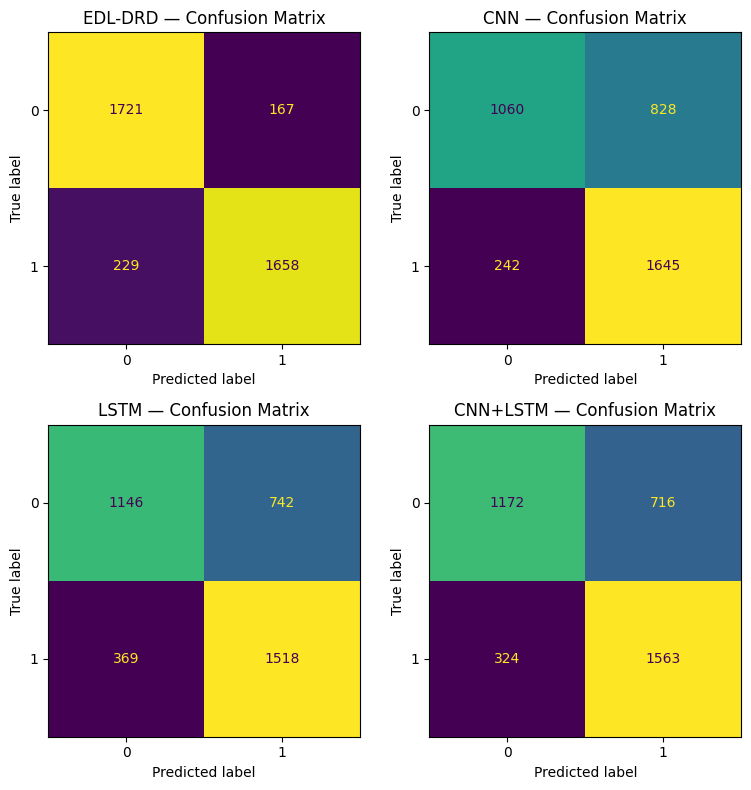

Saved: /content/model_comparison_fair.csv and /content/confusion_matrices_fair.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:

# Install, Imports, Params

!pip -q install openpyxl

import os, io, time, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.layers import (Input, Embedding, Conv1D, GlobalMaxPooling1D, MaxPooling1D,
                                     Dense, Dropout, Concatenate, LayerNormalization, Reshape,
                                     Rescaling, Softmax, Dot, LSTM, Bidirectional,
                                     GlobalAveragePooling1D, Add)
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 20000
MAX_LEN   = 100
EMB_DIM   = 64
CONV_F    = 64
LSTM_U    = 64
EPOCHS    = 10
BATCH     = 128
PATIENCE  = 2

BETA  = 0.8   # theory bias
GAMMA = 0.5   # semantic bias
ALPHA = 0.3   # aux-loss weight

os.environ["PYTHONHASHSEED"] = "42"
tf.keras.utils.set_random_seed(42)
try: tf.config.experimental.enable_op_determinism()
except: pass

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

# DatasetLoading
from google.colab import files
uploaded = files.upload()
xlsx_name = next(iter(uploaded))
df = pd.read_excel(io.BytesIO(uploaded[xlsx_name]), sheet_name=0)

first_col = df.columns[0]
last_col  = df.columns[-1]
df = df.rename(columns={first_col:"text", last_col:"label"})
df["text"]  = df["text"].astype(str)
df["label"] = df["label"].apply(
    lambda v: 1 if str(v).strip().lower() in {"1","true","yes","fake","deceptive","spam"} else 0
).astype(int)

print("Columns:", df.columns.tolist())
print(df.head(2))
print("Class balance:", df["label"].value_counts(normalize=True).round(3).to_dict())


# =========================
feat_cols_full_numeric = ['PM Ratio','FPSP Ratio','Review Length','RW Ratio','Sentiment',
                          'Generalization','Passive Voice','Total reviewer reviews',
                          'Useful votes','Attached Medias']
cat_col = 'Account type'
missing_full = [c for c in feat_cols_full_numeric+[cat_col] if c not in df.columns]
if missing_full:
    raise ValueError(f"Missing columns for EDL-DRD fusion: {missing_full}")

for c in feat_cols_full_numeric: df[c] = pd.to_numeric(df[c], errors='coerce')
df[feat_cols_full_numeric] = df[feat_cols_full_numeric].fillna(df[feat_cols_full_numeric].median(numeric_only=True))
df[cat_col] = df[cat_col].astype(str).fillna("unknown")

cat_dum_full = pd.get_dummies(df[cat_col], prefix="acct", dummy_na=False)
scaler_full = StandardScaler()
num_scaled_full = pd.DataFrame(scaler_full.fit_transform(df[feat_cols_full_numeric]),
                               columns=[f"sc_{c}" for c in feat_cols_full_numeric])

X_feats_full = pd.concat([num_scaled_full, cat_dum_full], axis=1)
feat_names_full = X_feats_full.columns.tolist()
X_feats_full = X_feats_full.values.astype('float32')
print("EDL-DRD (full) feature shape:", X_feats_full.shape)

baseline_feats_cols = ['PM Ratio','FPSP Ratio','Review Length','RW Ratio','Sentiment','Generalization','Passive Voice']
missing_base = [c for c in baseline_feats_cols if c not in df.columns]
if missing_base:
    raise ValueError(f"Missing columns for baselines: {missing_base}")

for c in baseline_feats_cols: df[c] = pd.to_numeric(df[c], errors='coerce')
df[baseline_feats_cols] = df[baseline_feats_cols].fillna(df[baseline_feats_cols].median(numeric_only=True))
scaler_base = StandardScaler()
X_feats_base = scaler_base.fit_transform(df[baseline_feats_cols]).astype('float32')
print("Baselines feature shape:", X_feats_base.shape)

# =========================
tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok.fit_on_texts(df['text'].str.lower())
seqs   = tok.texts_to_sequences(df['text'].str.lower())
X_text = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
y      = df['label'].values.astype('int32')

word_index = tok.word_index
HEDGES = set("maybe perhaps probably possibly generally typically kind sort almost seems appear apparently likely unlikely somehow".split())
INTENS = set("very really absolutely extremely totally completely incredibly highly perfectly utterly definitely certainly terribly unbelievably".split())
SUPERL = set("best worst greatest least most amazing awesome horrible terrible excellent fantastic awful unbelievable".split())
VAGUE  = set("some many few several lots bunch plenty nice good bad stuff things someone somewhere sometime".split())
SENS   = set("taste tasty flavorful sweet salty bitter spicy crunchy soft crispy smell aroma noisy quiet loud texture creamy tender juicy bright dark dim".split())

def ids_for(words): return {word_index[w] for w in words if w in word_index}
HEDGE_IDS, INTENS_IDS, SUPER_IDS, VAGUE_IDS, SENS_IDS = map(ids_for, [HEDGES,INTENS,SUPERL,VAGUE,SENS])

def build_cue_mask(seq):
    return [1.0 if tok in HEDGE_IDS or tok in INTENS_IDS or tok in SUPER_IDS or tok in VAGUE_IDS or tok in SENS_IDS else 0.0
            for tok in seq]

X_mask = np.array([build_cue_mask(s) for s in X_text], dtype='float32')
print("Shapes (text/mask/full_feats/base_feats):", X_text.shape, X_mask.shape, X_feats_full.shape, X_feats_base.shape, "| labels:", y.shape)

# =========================
if all(os.path.exists(f"/content/{n}.npy") for n in ["idx_tr","idx_va","idx_te"]):
    idx_tr = np.load("/content/idx_tr.npy"); idx_va = np.load("/content/idx_va.npy"); idx_te = np.load("/content/idx_te.npy")
else:
    idx_all = np.arange(len(df))
    idx_tr, idx_te = train_test_split(idx_all, test_size=0.15, random_state=42, stratify=y)
    idx_tr, idx_va = train_test_split(idx_tr, test_size=0.1765, random_state=4242, stratify=y[idx_tr])
    np.save("/content/idx_tr.npy", idx_tr); np.save("/content/idx_va.npy", idx_va); np.save("/content/idx_te.npy", idx_te)

X_text_tr, X_text_va, X_text_te = X_text[idx_tr], X_text[idx_va], X_text[idx_te]
X_mask_tr, X_mask_va, X_mask_te = X_mask[idx_tr], X_mask[idx_va], X_mask[idx_te]
Xf_full_tr, Xf_full_va, Xf_full_te = X_feats_full[idx_tr], X_feats_full[idx_va], X_feats_full[idx_te]
Xf_base_tr, Xf_base_va, Xf_base_te = X_feats_base[idx_tr], X_feats_base[idx_va], X_feats_base[idx_te]
y_tr, y_va, y_te = y[idx_tr], y[idx_va], y[idx_te]

print("Splits:", len(idx_tr), len(idx_va), len(idx_te))

# =========================

def build_edl_drd_fusion(beta=BETA, gamma=GAMMA, alpha=ALPHA, feats_dim=Xf_full_tr.shape[1]):
    # inputs
    inp_ids  = Input(shape=(MAX_LEN,), dtype='int32',   name='text_ids')
    inp_mask = Input(shape=(MAX_LEN,), dtype='float32', name='cue_mask')
    inp_f    = Input(shape=(feats_dim,), dtype='float32', name='feats_full')

    emb   = Embedding(MAX_VOCAB, EMB_DIM, name='emb')(inp_ids)       # [B,L,d]

    b3 = GlobalMaxPooling1D()(Conv1D(CONV_F, 3, activation='relu', padding='same')(emb))
    b4 = GlobalMaxPooling1D()(Conv1D(CONV_F, 4, activation='relu', padding='same')(emb))
    b5 = GlobalMaxPooling1D()(Conv1D(CONV_F, 5, activation='relu', padding='same')(emb))
    cnn_pool = Concatenate()([b3,b4,b5])                              # [B, 3*F]

    seq_h = Bidirectional(LSTM(LSTM_U, return_sequences=True,
                               dropout=0.2, recurrent_dropout=0.2))(emb)  # [B,L,2*U]


    sent_avg = GlobalAveragePooling1D()(emb)                     # [B,d]
    sent_avg_exp = Reshape((1, EMB_DIM))(sent_avg)               # [B,1,d]
    seq_proj = Dense(EMB_DIM, use_bias=False)(seq_h)             # [B,L,d]
    sem_scores_3d = Dot(axes=(2,2), name="semantic_dot")([seq_proj, sent_avg_exp])  # [B,L,1]
    sem_scores = Reshape((MAX_LEN,))(sem_scores_3d)              # [B,L]

    att_logits_3d = Dense(1)(seq_h)                              # [B,L,1]
    att_logits    = Reshape((MAX_LEN,))(att_logits_3d)           # [B,L]
    bias_theory   = Rescaling(beta)(inp_mask)                    # [B,L]
    bias_sem      = Rescaling(gamma)(sem_scores)                 # [B,L]
    biased        = Add(name='att_bias')([att_logits, bias_theory, bias_sem])
    att_w         = Softmax(axis=1, name='att_softmax')(biased)  # [B,L]
    att_w_exp     = Reshape((MAX_LEN,1))(att_w)
    context       = Dot(axes=(1,1))([att_w_exp, seq_h])          # [B,1,2*U]
    context       = Reshape((2*LSTM_U,))(context)                # [B,2*U]

    f = Dense(64, activation='relu')(inp_f)
    f = Dropout(0.3)(f)


    text_rep = Concatenate()([cnn_pool, context])                # [B, 3*F + 2U]
    rep = Concatenate()([text_rep, f])                           # [B, 3*F + 2U + 64]
    rep = LayerNormalization()(rep); rep = Dropout(0.5)(rep)


    aux_h   = Dense(64, activation='relu')(rep)
    aux_out = Dense(1, activation='sigmoid', name='aux_out')(aux_h)


    h = Dense(128, activation='relu')(rep); h = Dropout(0.5)(h)
    main_out = Dense(1, activation='sigmoid', name='main_out')(h)

    model = Model(inputs={'text_ids':inp_ids,'cue_mask':inp_mask,'feats_full':inp_f},
                  outputs={'main_out':main_out,'aux_out':aux_out},
                  name='EDL_DRD_FUSION_FULL')
    model.compile(optimizer=Adam(1e-3),
                  loss={'main_out':'binary_crossentropy','aux_out':'binary_crossentropy'},
                  loss_weights={'main_out':1.0,'aux_out':alpha},
                  metrics={'main_out':['accuracy'],'aux_out':['accuracy']})
    return model

def small_feats_branch_base(inp):
    x = Dense(16, activation='relu')(inp)
    return Dropout(0.2)(x)

def build_cnn_baseline():
    inp_ids  = Input(shape=(MAX_LEN,), dtype='int32', name='text_ids')
    inp_fb   = Input(shape=(Xf_base_tr.shape[1],), dtype='float32', name='feats_base')
    x = Embedding(MAX_VOCAB, EMB_DIM)(inp_ids)
    b3 = GlobalMaxPooling1D()(Conv1D(CONV_F,3,activation='relu',padding='same')(x))
    b4 = GlobalMaxPooling1D()(Conv1D(CONV_F,4,activation='relu',padding='same')(x))
    b5 = GlobalMaxPooling1D()(Conv1D(CONV_F,5,activation='relu',padding='same')(x))
    txt = Concatenate()([b3,b4,b5])
    fb  = small_feats_branch_base(inp_fb)
    rep = Concatenate()([txt, fb])
    rep = LayerNormalization()(rep); rep = Dropout(0.5)(rep)
    rep = Dense(128, activation='relu')(rep); rep = Dropout(0.5)(rep)
    out = Dense(1, activation='sigmoid', name='main_out')(rep)
    m = Model(inputs={'text_ids':inp_ids,'feats_base':inp_fb}, outputs=out, name='CNN_BASE')
    m.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_lstm_baseline():
    inp_ids  = Input(shape=(MAX_LEN,), dtype='int32', name='text_ids')
    inp_fb   = Input(shape=(Xf_base_tr.shape[1],), dtype='float32', name='feats_base')
    x = Embedding(MAX_VOCAB, EMB_DIM)(inp_ids)
    txt = Bidirectional(LSTM(LSTM_U, return_sequences=False, dropout=0.2, recurrent_dropout=0.2))(x)
    fb  = small_feats_branch_base(inp_fb)
    rep = Concatenate()([txt, fb])
    rep = LayerNormalization()(rep); rep = Dropout(0.5)(rep)
    rep = Dense(128, activation='relu')(rep); rep = Dropout(0.5)(rep)
    out = Dense(1, activation='sigmoid', name='main_out')(rep)
    m = Model(inputs={'text_ids':inp_ids,'feats_base':inp_fb}, outputs=out, name='LSTM_BASE')
    m.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_cnnlstm_baseline():
    inp_ids  = Input(shape=(MAX_LEN,), dtype='int32', name='text_ids')
    inp_fb   = Input(shape=(Xf_base_tr.shape[1],), dtype='float32', name='feats_base')
    x = Embedding(MAX_VOCAB, EMB_DIM)(inp_ids)
    x = Conv1D(CONV_F, 3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    txt = LSTM(LSTM_U, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(x)
    fb  = small_feats_branch_base(inp_fb)
    rep = Concatenate()([txt, fb])
    rep = LayerNormalization()(rep); rep = Dropout(0.5)(rep)
    rep = Dense(128, activation='relu')(rep); rep = Dropout(0.5)(rep)
    out = Dense(1, activation='sigmoid', name='main_out')(rep)
    m = Model(inputs={'text_ids':inp_ids,'feats_base':inp_fb}, outputs=out, name='CNNLSTM_BASE')
    m.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
    return m

# =========================
def _in_names(model):  return [t.name.split(':')[0] for t in model.inputs]
def _out_names(model): return list(model.output_names)

def _pack_inputs(model, split='train'):
    sel = {'train':0,'val':1,'test':2}[split]
    d = {}
    for n in _in_names(model):
        if n.endswith('text_ids'):     d[n] = [X_text_tr, X_text_va, X_text_te][sel]
        elif n.endswith('cue_mask'):   d[n] = [X_mask_tr, X_mask_va, X_mask_te][sel]
        elif n.endswith('feats_full'): d[n] = [Xf_full_tr, Xf_full_va, Xf_full_te][sel]
        elif n.endswith('feats_base'): d[n] = [Xf_base_tr, Xf_base_va, Xf_base_te][sel]
        else: raise ValueError(f"Unknown input: {n}")
    return d

def _pack_targets(model, split='train'):
    outs = _out_names(model)
    y_map = {'train':y_tr, 'val':y_va, 'test':y_te}
    if 'aux_out' in outs and 'main_out' in outs:
        return {'main_out': y_map[split], 'aux_out': y_map[split]}
    return y_map[split]

def _get_probs(model, inputs):
    out = model.predict(inputs, verbose=0)
    if isinstance(out, dict):         return out['main_out'].ravel()
    if isinstance(out, (list,tuple)): return out[0].ravel()
    return out.ravel()

def sweep_threshold(prob, y, steps=61):
    ts = np.linspace(0.05, 0.95, steps)
    rows=[]
    for t in ts:
        yhat = (prob >= t).astype(int)
        rows.append([t,
                     accuracy_score(y, yhat),
                     precision_score(y, yhat, zero_division=0),
                     recall_score(y, yhat, zero_division=0),
                     f1_score(y, yhat, zero_division=0)])
    return pd.DataFrame(rows, columns=['thr','acc','prec','rec','f1'])

def train_and_eval(build_fn, label, metric_for_thr='f1'):
    print(f"\n▶ Training {label}")
    model = build_fn()
    cb = [
        EarlyStopping(monitor='val_loss', mode='min', patience=PATIENCE, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5, patience=1, min_lr=1e-5, verbose=1)
    ]
    tr_in, va_in = _pack_inputs(model, 'train'), _pack_inputs(model, 'val')
    tr_y,  va_y  = _pack_targets(model, 'train'), _pack_targets(model, 'val')

    t0 = time.time()
    model.fit(tr_in, tr_y, validation_data=(va_in, va_y),
              epochs=EPOCHS, batch_size=BATCH, callbacks=cb, verbose=1)
    print(f"   Time: {time.time()-t0:.1f}s")

    val_prob = _get_probs(model, va_in)
    df_thr   = sweep_threshold(val_prob, y_va, steps=61)
    best_thr = float(df_thr.loc[df_thr[metric_for_thr].idxmax(),'thr'])
    print(f"   Best threshold on val ({metric_for_thr}): {best_thr:.2f}")

    te_in = _pack_inputs(model, 'test')
    te_prob = _get_probs(model, te_in)
    yhat = (te_prob >= best_thr).astype(int)
    res = dict(label=label, thr=best_thr,
               acc=accuracy_score(y_te, yhat),
               prec=precision_score(y_te, yhat, zero_division=0),
               rec=recall_score(y_te, yhat, zero_division=0),
               f1=f1_score(y_te, yhat, zero_division=0))
    print(f"   Test: acc={res['acc']:.3f} prec={res['prec']:.3f} rec={res['rec']:.3f} f1={res['f1']:.3f}")
    return model, res, yhat

def plot_conf_matrix(y_true, y_pred, title, ax=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    if ax is None:
        fig, ax = plt.subplots(figsize=(4,4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    return cm

# =========================
models, results, preds = [], [], []

edlF_model, edlF_res, edlF_pred = train_and_eval(lambda: build_edl_drd_fusion(beta=BETA, gamma=GAMMA, alpha=ALPHA), "EDL-DRD")
cnnB_model, cnnB_res, cnnB_pred   = train_and_eval(build_cnn_baseline,   "CNN")
lstmB_model, lstmB_res, lstmB_pred= train_and_eval(build_lstm_baseline,  "LSTM")
clB_model, clB_res, clB_pred      = train_and_eval(build_cnnlstm_baseline,"CNN+LSTM")


models  += [edlF_model, cnnB_model, lstmB_model, clB_model]
results += [edlF_res,   cnnB_res,   lstmB_res,   clB_res  ]
preds   += [edlF_pred,  cnnB_pred,  lstmB_pred,  clB_pred ]

df_res = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
print("\n=== Fair Comparison: EDL-DRD vs CNN/LSTM/CNN-LSTM ===")
print(df_res)

# Confusion Matrices
fig, axes = plt.subplots(2,2, figsize=(8,8))
titles = ["EDL-DRD", "CNN", "LSTM", "CNN+LSTM"]
for ax, title, yhat in zip(axes.ravel(), titles, preds):
    plot_conf_matrix(y_te, yhat, f"{title} — Confusion Matrix", ax=ax)
plt.tight_layout()
plt.savefig("/content/confusion_matrices_fair.png", dpi=300)
plt.show()

# Save
df_res.to_csv("/content/model_comparison_fair.csv", index=False)
with open("/content/tokenizer.json","w") as f: f.write(tok.to_json())

print("Saved:", "/content/model_comparison_fair.csv", "and", "/content/confusion_matrices_fair.png")
from google.colab import files
files.download("/content/model_comparison_fair.csv")
 files.download("/content/confusion_matrices_fair.png")
